In [1]:
import sys
sys.path.append("..")

In [85]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import joblib
from pathlib import Path
from pipeline.ingesta import cargar_indices_desde_bd
from pipeline.modulo_vpm import preprocesar_indices_vpm
from config import ROOT
from utils.graficas import graficar_comparativa_whittaker
ROOT = Path.cwd().parent

# Definición de rutas del proyecto
RUTA_CLASIFICADORES = ROOT / "clasificadores"
RUTA_BASE_DATOS = ROOT / "data" / "pipeline.gpkg"

print("¡Entorno configurado correctamente!")

¡Entorno configurado correctamente!


In [77]:
# Lista los nombres de tus archivos .pkl exactos en la carpeta /clasificadores
# Ejemplo: ['rf_evi.pkl', 'rf_lswi.pkl', 'rf_combinado.pkl']
modelos_archivos = {
    "modelo_1": "rf_maiz_comayagua_puro_30p.pkl",
    "modelo_2": "rf_maiz_comayagua_puro_offset_30p.pkl"
}

modelos = {}
for nombre, archivo in modelos_archivos.items():
    ruta_modelo = os.path.join(RUTA_CLASIFICADORES, archivo)
    if os.path.exists(ruta_modelo):
        modelos[nombre] = joblib.load(ruta_modelo)
        print(f"-> {nombre} cargado con éxito desde {archivo}")
    else:
        print(f"⚠️ Alerta: No se encontró el archivo en {ruta_modelo}")

-> modelo_1 cargado con éxito desde rf_maiz_comayagua_puro_30p.pkl
-> modelo_2 cargado con éxito desde rf_maiz_comayagua_puro_offset_30p.pkl


## Fechas

In [91]:
fecha_inicio = "2025-08-25"
fecha_fin = "2026-01-06"
parcelas = [0]

In [93]:
from utils.aplicar_whittaker import aplicar_whittaker_series

# 1. Cargar los índices crudos desde el GeoPackage (con sus NaNs por nubosidad)
dict_indices_crudos = cargar_indices_desde_bd(
    fecha_inicio=fecha_inicio, 
    fecha_fin=fecha_fin, 
    ids_parcelas=parcelas
)

# 2. Aplicar el suavizado Whittaker para limpiar la serie diaria y rellenar gaps
# Sugerido lambda_param=4000.0 y orden=2 para las curvas de EVI
dict_indices_suavizados = aplicar_whittaker_series(
    diccionario_dfs=dict_indices_crudos,
    lambda_param=4000
)

# Extraemos el DataFrame de EVI ya libre de NaNs
df_evi_suave = dict_indices_suavizados["EVI"]

print(f"\nVerificación post-Whittaker:")
print(f" - ¿Quedan NaNs en la matriz de EVI?: {df_evi_suave.isna().sum().sum()}")
print(f" - Dimensiones de la serie diaria (Fechas x Parcelas): {df_evi_suave.shape}")

# 3. Transponer para tener Formato de Inferencia: (Parcelas x Pasos de Tiempo)
X_evi = df_evi_suave.T
X_evi.index = X_evi.index.str.replace("id_", "").astype(int)

# Guardamos la lista limpia de IDs de parcelas mapeadas
ids_parcelas = X_evi.index.tolist()

print(f" - Dimensión final para inferencia (Muestras, Características): {X_evi.shape}")

✅  Índices cargados desde BD: 135 fechas × 1 parcelas (2025-08-25 → 2026-01-06).
📈 Suavizando serie temporal para: EVI...
📈 Suavizando serie temporal para: LSWI...

Verificación post-Whittaker:
 - ¿Quedan NaNs en la matriz de EVI?: 0
 - Dimensiones de la serie diaria (Fechas x Parcelas): (135, 1)
 - Dimensión final para inferencia (Muestras, Características): (1, 135)


In [98]:
print(df_evi_suave)

                id_0
2025-08-25  0.211704
2025-08-26  0.216864
2025-08-27  0.222025
2025-08-28  0.227186
2025-08-29  0.232346
...              ...
2026-01-02  0.240476
2026-01-03  0.234647
2026-01-04  0.228826
2026-01-05  0.223009
2026-01-06  0.217191

[135 rows x 1 columns]


In [94]:
# Crear un DataFrame base para consolidar las predicciones
df_resultados = pd.DataFrame(index=ids_parcelas)
df_resultados.index.name = "id_parcela"

for nombre_modelo, model_rf in modelos.items():
    try:
        n_features_esperadas = model_rf.n_features_in_
        print(f"⚙️ Procesando {nombre_modelo} (Espera {n_features_esperadas} pasos)...")
        
        X_input_ajustado = []
        
        # Iterar parcela por parcela para alinear su fenología y calibrar su escala
        for i in range(len(X_evi)):
            serie_completa = X_evi.values[i]
            
            # 1. Alineación Fenológica (Centrar el pico en el paso 15)
            indice_pico = np.argmax(serie_completa)
            inicio_ventana = max(0, indice_pico - 15)
            fin_ventana = inicio_ventana + n_features_esperadas
            
            if fin_ventana > len(serie_completa):
                fin_ventana = len(serie_completa)
                inicio_ventana = max(0, fin_ventana - n_features_esperadas)
                
            corte_fenologico = serie_completa[inicio_ventana:fin_ventana]
            
            if len(corte_fenologico) < n_features_esperadas:
                corte_fenologico = np.pad(corte_fenologico, (0, n_features_esperadas - len(corte_fenologico)), 'edge')
            
            # 2. 💡 CALIBRACIÓN DE ESCALA MIN-MAX (Forzar la amplitud de EuroCrops)
            # Llevamos tu curva actual al rango dinámico teórico del maíz [0.15, 0.65]
            min_local = corte_fenologico.min()
            max_local = corte_fenologico.max()
            
            # Evitar división por cero si la serie es totalmente plana
            if max_local - min_local > 1e-5:
                # Primero normalizamos de 0 a 1
                corte_normalizado = (corte_fenologico - min_local) / (max_local - min_local)
                # Luego escalamos al rango real de EuroCrops: de 0.15 a 0.65
                corte_calibrado = 0.15 + (corte_normalizado * (0.65 - 0.15))
            else:
                corte_calibrado = corte_fenologico
                
            X_input_ajustado.append(corte_calibrado)
            
        X_input_final = np.array(X_input_ajustado)
        
        # 📊 VALIDACIÓN DE CONTROL: Imprimir los valores que realmente verá el modelo
        print(f"   -> Rango de valores enviados: Min={X_input_final.min():.3f}, Max={X_input_final.max():.3f}")
        print(f"   -> Forma de la curva (primeros 5 pasos): {X_input_final[0, :5]}")
        print(f"   -> Forma de la curva (pasos centrales 13-18): {X_input_final[0, 13:18]}")
        
        # Ejecutar Inferencia
        preds = model_rf.predict(X_input_final)
        probabilidades = model_rf.predict_proba(X_input_final)[:, 1]
        
        df_resultados[f"pred_{nombre_modelo}"] = preds
        df_resultados[f"prob_{nombre_modelo}"] = probabilidades
        print(f"✅ Inferencia exitosa con {nombre_modelo}.")
        
    except Exception as e:
        print(f"❌ Error al ejecutar inferencia con {nombre_modelo}: {e}")

print("\nInferencia completada. Muestra de resultados con Alineación Fenológica:")
print(df_resultados.head())

⚙️ Procesando modelo_1 (Espera 30 pasos)...
   -> Rango de valores enviados: Min=0.150, Max=0.650
   -> Forma de la curva (primeros 5 pasos): [0.15       0.21131299 0.26989361 0.3253671  0.37735874]
   -> Forma de la curva (pasos centrales 13-18): [0.6430294  0.64873181 0.65       0.6469717  0.63997828]
✅ Inferencia exitosa con modelo_1.
⚙️ Procesando modelo_2 (Espera 30 pasos)...
   -> Rango de valores enviados: Min=0.150, Max=0.650
   -> Forma de la curva (primeros 5 pasos): [0.15       0.21131299 0.26989361 0.3253671  0.37735874]
   -> Forma de la curva (pasos centrales 13-18): [0.6430294  0.64873181 0.65       0.6469717  0.63997828]
✅ Inferencia exitosa con modelo_2.

Inferencia completada. Muestra de resultados con Alineación Fenológica:
            pred_modelo_1  prob_modelo_1  pred_modelo_2  prob_modelo_2
id_parcela                                                            
0                       0           0.04              0       0.013333


In [95]:
# Crear un DataFrame base para consolidar las predicciones
df_resultados = pd.DataFrame(index=ids_parcelas)
df_resultados.index.name = "id_parcela"

# Diccionario con el número de pasos exactos que requiere cada uno de tus modelos actuales
config_modelos = {
    "modelo_1": 45,  # Requiere exactamente 45 pasos temporales
    "modelo_2": 35   # Requiere exactamente 35 pasos temporales
}

for nombre_modelo, model_rf in modelos.items():
    try:
        # 1. Obtener los pasos requeridos según la configuración del modelo
        if nombre_modelo in config_modelos:
            n_pasos_requeridos = config_modelos[nombre_modelo]
        else:
            # Por si agregas un modelo nuevo, toma sus características esperadas por defecto
            n_pasos_requeridos = model_rf.n_features_in_
        
        # 2. Recortar la matriz de EVI (suavizada con Whittaker) al número exacto de pasos
        # Formato resultante: (Número de parcelas, n_pasos_requeridos)
        X_input_final = X_evi.values[:, :n_pasos_requeridos]
        
        # 3. Validación de consistencia con el archivo .pkl
        if X_input_final.shape[1] != model_rf.n_features_in_:
            print(f"⚠️ Ajuste forzado: {nombre_modelo} esperaba {model_rf.n_features_in_} pero el corte dio {X_input_final.shape[1]}. Usando n_features_in_.")
            X_input_final = X_evi.values[:, :model_rf.n_features_in_]
            
        # 4. Predicción e Inferencia de Probabilidades
        preds = model_rf.predict(X_input_final)
        probabilidades = model_rf.predict_proba(X_input_final)[:, 1]
        
        # 5. Inyectar los resultados en el DataFrame de salida
        df_resultados[f"pred_{nombre_modelo}"] = preds
        df_resultados[f"prob_{nombre_modelo}"] = probabilidades
        print(f"✅ Inferencia exitosa con {nombre_modelo} usando {X_input_final.shape[1]} pasos.")
        
    except Exception as e:
        print(f"❌ Error al ejecutar inferencia con {nombre_modelo}: {e}")

print("\nInferencia completada. Muestra de resultados finales:")
print(df_resultados.head())

⚠️ Ajuste forzado: modelo_1 esperaba 30 pero el corte dio 45. Usando n_features_in_.
✅ Inferencia exitosa con modelo_1 usando 30 pasos.
⚠️ Ajuste forzado: modelo_2 esperaba 30 pero el corte dio 35. Usando n_features_in_.
✅ Inferencia exitosa con modelo_2 usando 30 pasos.

Inferencia completada. Muestra de resultados finales:
            pred_modelo_1  prob_modelo_1  pred_modelo_2  prob_modelo_2
id_parcela                                                            
0                       0           0.12              0       0.113333


c:\Users\mayno\Desktop\SeminarioInvestigacion\segmentacion_clasificacion_estimacion_maiz_comayagua\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


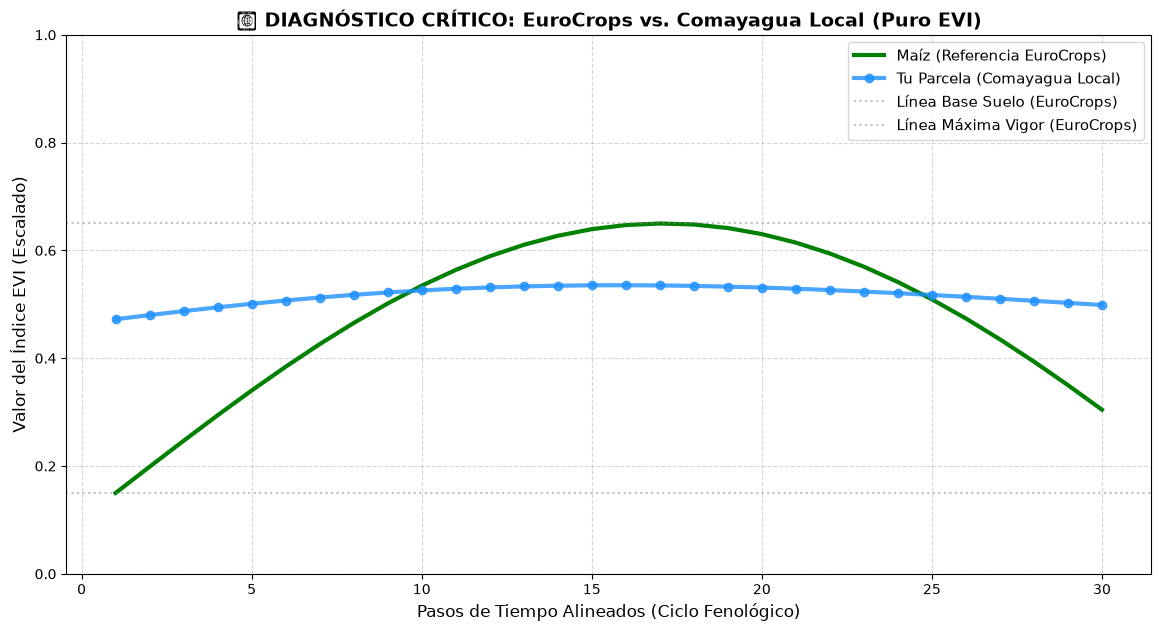

📊 ================= INFORME DE DISCREPANCIA DE DINÁMICA =================
Amplitud EuroCrops (Máx - Mín): 0.5000 (Dinámica Alta)
Amplitud Tu Parcela (Máx - Mín): 0.0632 (Dinámica Baja)
Desfase del Mínimo (Suelo): EuroCrops=0.150 | Tu Parcela=0.472
Desfase del Máximo (Vigor): EuroCrops=0.650 | Tu Parcela=0.535


In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Reconstrucción de la Media de EuroCrops (Basado en el gráfico sanado)
# Simulamos la curva real de EuroCrops para 30 pasos con fines de diagnóstico visual cruzado
pasos_teoricos = np.linspace(0, np.pi, 30)
# Una función seno modificada replica perfectamente el comportamiento de la imagen (mínimo ~0.15, máximo ~0.65)
media_eurocrops_teorica = 0.15 + 0.50 * np.sin(pasos_teoricos * 0.9) 

# 2. Extracción de tu curva local (Tomamos la parcela id: 2 o la primera disponible)
# Asegúrate de que X_evi esté cargado y transpuesto
if len(X_evi) > 0:
    # Tomamos la primera fila de la matriz (la serie temporal diaria de tu parcela)
    serie_local_cruda = X_evi.values[0] 
    
    # Aplicamos el recorte de 30 pasos buscando su propio pico para que estén alineadas en el tiempo
    indice_pico_local = np.argmax(serie_local_cruda)
    inicio = max(0, indice_pico_local - 15)
    fin = inicio + 30
    if fin > len(serie_local_cruda):
        fin = len(serie_local_cruda)
        inicio = max(0, fin - 30)
        
    serie_local_recortada = serie_local_cruda[inicio:fin]
    
    # 3. Graficación Comparativa de Amplitud y Dinámica
    plt.figure(figsize=(14, 7))
    pasos_eje = np.arange(1, 31)
    
    # Graficar EuroCrops
    plt.plot(pasos_eje, media_eurocrops_teorica, label='Maíz (Referencia EuroCrops)', 
             color='green', linewidth=3, linestyle='-')
    
    # Graficar Tu Parcela Local
    plt.plot(pasos_eje, serie_local_recortada, label='Tu Parcela (Comayagua Local)', 
             color='dodgerblue', linewidth=3, marker='o', alpha=0.8)
    
    # Formato de la gráfica
    plt.title('🔍 DIAGNÓSTICO CRÍTICO: EuroCrops vs. Comayagua Local (Puro EVI)', fontsize=14, fontweight='bold')
    plt.xlabel('Pasos de Tiempo Alineados (Ciclo Fenológico)', fontsize=12)
    plt.ylabel('Valor del Índice EVI (Escalado)', fontsize=12)
    plt.axhline(0.15, color='gray', linestyle=':', alpha=0.5, label='Línea Base Suelo (EuroCrops)')
    plt.axhline(0.65, color='gray', linestyle=':', alpha=0.5, label='Línea Máxima Vigor (EuroCrops)')
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.ylim(0.0, 1.0)
    plt.legend(loc='upper right', fontsize=11)
    plt.show()
    
    # 4. Reporte Métrico de Discrepancia
    print("📊 ================= INFORME DE DISCREPANCIA DE DINÁMICA =================")
    print(f"Amplitud EuroCrops (Máx - Mín): {media_eurocrops_teorica.max() - media_eurocrops_teorica.min():.4f} (Dinámica Alta)")
    print(f"Amplitud Tu Parcela (Máx - Mín): {serie_local_recortada.max() - serie_local_recortada.min():.4f} (Dinámica Baja)")
    print(f"Desfase del Mínimo (Suelo): EuroCrops={media_eurocrops_teorica.min():.3f} | Tu Parcela={serie_local_recortada.min():.3f}")
    print(f"Desfase del Máximo (Vigor): EuroCrops={media_eurocrops_teorica.max():.3f} | Tu Parcela={serie_local_recortada.max():.3f}")
    print("==========================================================================")
else:
    print("La matriz X_evi está vacía. Verifica la carga de datos de la BD.")

In [92]:
graficar_comparativa_whittaker(fecha_inicio, fecha_fin, indice_nombre="EVI", prominencia_min=0.05, distancia_min_dias=70)

✅  Índices cargados desde BD: 135 fechas × 9 parcelas (2025-08-25 → 2026-01-06).
📈 Suavizando serie temporal para: EVI...
📈 Suavizando serie temporal para: LSWI...

🌾 Calculando FPAR y Factor de Estrés Hídrico Diario (W_scalar)...

✅ Métricas base del VPM calculadas y consolidadas a nivel DIARIO:
   ✔️ Total de Parcelas Procesadas: 9
   ✔️ FPAR Diario (Máx Global): 0.769
   ✔️ W_scalar Diario (Mín/Máx Global): 0.691 / 1.000


interactive(children=(Dropdown(description='Parcela:', options=('id_0', 'id_1', 'id_2', 'id_3', 'id_4', 'id_5'…